In [10]:
import cv2
import time
import numpy as np
import statistics
import matplotlib.pyplot as plt

def run_inference(model, frame):
    # ======================================
    # 1. Scale input frame
    # ======================================
    """Reading the image"""
    x = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    x = x / 255.0
    x = x.astype(np.float32) # Change the data type to float32
    # print(x.shape)
    x = np.expand_dims(x, axis=0)  ## this expands the dimension and makes it into a batch/list of images
    # print(x.shape)



    # ======================================
    # 2. Feed the scaled frame to the model
    # ======================================
    # Perform road segmentation on the frame
    # road_mask = segment_road(x, model)
    # road_mask = road_mask # The mask is already in the desired format (720, 1280, 3) from segment_road

    """Run model inference on a single frame"""
    # -----------------------------------------------------------------
    # --------------------- START the TIME ----------------------------
    start_time = time.time()
    # output = model.predict(frame)   # replace with your inference call
    road_mask = segment_road(x, model)

    # ======================================
    # 3. Feed predicted mask to post_process
    # ======================================
    maskFinal, maskFinal_Gray, segmented_frame, imageTest, redGRID, Lines = postProcess__(road_mask, frame, frame_count)

    end_time = time.time()
    # --------------------- END the TIME ----------------------------
    # -----------------------------------------------------------------
    return redGRID, (end_time - start_time)

def process_video(video_path, output_path, model, benchmark_mode=True, num_runs=5):
    cap = cv2.VideoCapture(video_path)
    # Get video properties
    fps = video_capture.get(cv2.CAP_PROP_FPS)
    width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))


    # Define the codec for output video
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    output_video = cv2.VideoWriter(output_path, fourcc, fps, (width, height))


    import csv
    #csv_filename = "C:/Users/dheer/Downloads/outputs/inference_times.csv"
    csv_filename = output_folder + "inference_times.csv"

    with open(csv_filename, mode="w", newline="") as csv_file:
      # Create a CSV writer
      csv_writer = csv.writer(csv_file)

      # Write the header row
      csv_writer.writerow(["frame_count", "Inference Time (seconds)", "frame_count", "total_inference_time", "average_inference_time"])

      total_inference_time = 0
      frame_idx = 0
      while cap.isOpened():
          ret, frame = cap.read()
          if not ret:
              break

          frame_idx += 1

          if benchmark_mode:
              # Run multiple times per frame
              times = []
              final_output = None
              for i in range(num_runs):
                  print(f"\n--- Iteration {i+1} ---")
                  output, elapsed = run_inference(model, frame)
                  times.append(elapsed)
                  print(f"Inference time: {elapsed:.4f} sec")
                  final_output = output  # keep the last output for post-processing

              median_time = np.median(times)
              print(f"Frame {frame_idx}: median inference time over {num_runs} runs = {median_time:.4f} sec")
              csv_writer.writerow([frame_idx, median_time])

              total_inference_time += median_time

              # -----------------------------------------------------------
              # Write the processed frame to the output video file
              # -----------------------------------------------------------
              output_video.write(final_output)

          else:
              # Normal real-time mode
              output, elapsed = run_inference(model, frame)
              print(f"Frame {frame_idx}: inference time = {elapsed:.4f} sec")

              csv_writer.writerow([frame_idx, elapsed])

              total_inference_time += elapsed

              # -----------------------------------------------------------
              # Write the processed frame to the output video file
              # -----------------------------------------------------------
              output_video.write(output)


          print(f"Total number of frames: {frame_idx}")
          print(f"Total inference time accross {frame_idx} frames: {total_inference_time}")
          average_inference_time = total_inference_time / frame_idx
          print(f"Average Inference Time from {frame_idx} = ({total_inference_time} / {frame_idx}) = {average_inference_time} seconds")

      # "frame_count", "Inference Time (seconds)", "frame_count", "total_inference_time", "average_inference_time"
      csv_writer.writerow([0, 0, frame_idx, total_inference_time, average_inference_time])



          # Optional: display or process the output
          # # ======================================
          # # Show the output frame
          # # ======================================

          # plt.imshow(tf.keras.preprocessing.image.array_to_img(final_output))
          # plt.axis('off')
          # plt.show()

    cap.release()
    cv2.destroyAllWindows()


process_video(video_path, output_path, model, benchmark_mode=False, num_runs=5)


Frame 1: inference time = 0.1508 sec
Total number of frames: 1
Total inference time accross 1 frames: 0.15082812309265137
Average Inference Time from 1 = (0.15082812309265137 / 1) = 0.15082812309265137 seconds
Frame 2: inference time = 0.1424 sec
Total number of frames: 2
Total inference time accross 2 frames: 0.2932243347167969
Average Inference Time from 2 = (0.2932243347167969 / 2) = 0.14661216735839844 seconds
Frame 3: inference time = 0.1423 sec
Total number of frames: 3
Total inference time accross 3 frames: 0.4355506896972656
Average Inference Time from 3 = (0.4355506896972656 / 3) = 0.14518356323242188 seconds
Frame 4: inference time = 0.1430 sec
Total number of frames: 4
Total inference time accross 4 frames: 0.5785682201385498
Average Inference Time from 4 = (0.5785682201385498 / 4) = 0.14464205503463745 seconds
Frame 5: inference time = 0.1413 sec
Total number of frames: 5
Total inference time accross 5 frames: 0.7198758125305176
Average Inference Time from 5 = (0.7198758125

In [8]:

# To store all inference times
inference_times = []

# Run the model 5 times on the same frame
for i in range(5):
    print(f"\n--- Iteration {i+1} ---")

    # ======================================
    # 3. Start inference timer
    # ======================================
    start_time = time.time()

    # ======================================
    # 4. Scale input frame
    # ======================================
    """Reading the image"""
    x = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    x = x / 255.0
    x = x.astype(np.float32) # Change the data type to float32
    # print(x.shape)
    x = np.expand_dims(x, axis=0)  ## this expands the dimension and makes it into a batch/list of images
    # print(x.shape)



    # ======================================
    # 5. Feed the scaled frame to the model
    # ======================================
    # Perform road segmentation on the frame
    road_mask = segment_road(x, model)

    road_mask = road_mask # The mask is already in the desired format (720, 1280, 3) from segment_road

    # ======================================
    # 6. Predict the mask (already from run_model)
    # ======================================

    # Resize the original frame to match the mask dimensions
    resized_frame = cv2.resize(frame, (road_mask.shape[1], road_mask.shape[0]))

    # ======================================
    # 7. Feed predicted mask to post_process
    # ======================================
    maskFinal, maskFinal_Gray, segmented_frame, imageTest, redGRID, Lines = postProcess__(road_mask, frame, frame_count)

    # ======================================
    # 8. End inference timer
    # ======================================
    end_time = time.time()

    # ======================================
    # Calculate and store the inference time
    # ======================================
    inf_time = end_time - start_time
    inference_times.append(inf_time)

    # ======================================
    # 9. Print results
    # ======================================
    print(f"Inference time: {end_time - start_time:.4f} sec")


    # # ======================================
    # # Show the output frame
    # # ======================================
    # import matplotlib.pyplot as plt
    # plt.imshow(tf.keras.preprocessing.image.array_to_img(redGRID))
    # plt.axis('off')
    # plt.show()

# ---------------- Median Calculation ---------------- #
median_time = np.median(inference_times)
# print(inference_times)
print("\n===========================")
print(f"Median inference time (5 runs): {median_time:.4f} sec")
print("===========================")



--- Iteration 1 ---
Inference time: 0.1480 sec

--- Iteration 2 ---
Inference time: 0.1414 sec

--- Iteration 3 ---
Inference time: 0.1552 sec

--- Iteration 4 ---
Inference time: 0.1432 sec

--- Iteration 5 ---
Inference time: 0.1402 sec

Median inference time (5 runs): 0.1432 sec


## **TESTING SINGLE FRAME CELL**

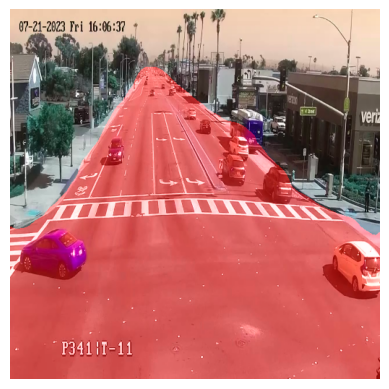

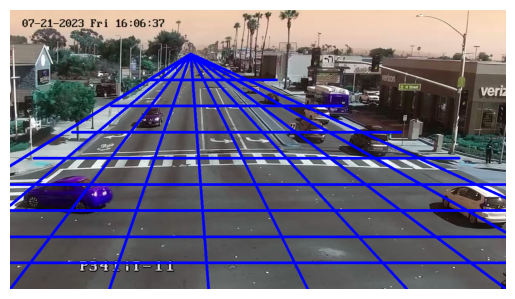

In [7]:

frame = cv2.imread('/content/drive/MyDrive/Colab Notebooks/frame_INPUT_313.jpg')

# Check if the image was loaded successfully
if frame is None:
    print("Error: Image not loaded. Please check the file path.")
else:
    frame_count = 0

    """Reading the image"""
    x = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
    x = x / 255.0
    x = x.astype(np.float32) # Change the data type to float32
    # print(x.shape)
    x = np.expand_dims(x, axis=0)  ## this expands the dimension and makes it into a batch/list of images
    # print(x.shape)

    # Perform road segmentation on the frame
    road_mask = segment_road(x, model)

    road_mask = road_mask # The mask is already in the desired format (720, 1280, 3) from segment_road


    # Resize the original frame to match the mask dimensions
    resized_frame = cv2.resize(frame, (road_mask.shape[1], road_mask.shape[0]))

    # Apply the road mask to the frame
    processed_frame = weighted_img(road_mask, resized_frame)

    maskFinal, maskFinal_Gray, segmented_frame, imageTest, redGRID, Lines = postProcess__(road_mask, frame, frame_count)

import matplotlib.pyplot as plt
plt.imshow(tf.keras.preprocessing.image.array_to_img(processed_frame))
plt.axis('off')
plt.show()

import matplotlib.pyplot as plt
plt.imshow(tf.keras.preprocessing.image.array_to_img(redGRID))
plt.axis('off')
plt.show()

## **LOAD MODEL CELL  & COMPILE**

In [6]:
# Recreate the model architecture
model = deeplabv3_plus((H, W, 3))

model.load_weights(model_path)

# Compile the model with the same custom objects
model.compile(
    loss=dice_loss,
    optimizer=tf.keras.optimizers.Adam(LR), # Use tf.keras.optimizers.Adam
    metrics=[dice_coef, iou, tf.keras.metrics.Recall(), tf.keras.metrics.Precision(), tf.keras.metrics.BinaryAccuracy()]
)

print("Model loaded and weights loaded successfully.")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Model loaded and weights loaded successfully.


## **FILE PATHS CELL**

In [5]:
# ---------------------------
# File PATHS
# ---------------------------

video_path = "/content/drive/MyDrive/Colab Notebooks/input__VideoStream.mp4"

# video_path = "/content/drive/MyDrive/Colab Notebooks/original__finalCUT___8008.mp4"

model_path = "/content/drive/MyDrive/Colab Notebooks/submitted_model.h5"

output_folder = "/content/output"

output_path = output_folder + "outputGRID.mp4"



video_capture = cv2.VideoCapture(video_path)
# Get video properties
fps = video_capture.get(cv2.CAP_PROP_FPS)
width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))

## **PROCESSING PIPELINE CELL**

In [3]:
def postProcess__(mask, inputImage, frame_count):
    KERNEL_SIZE = 20

    # Load the road segmentation mask image

    mask__gray = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)


    # Apply morphological openings to remove all small raod openings
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (KERNEL_SIZE, KERNEL_SIZE))
    mask_changed = cv2.morphologyEx(mask__gray, cv2.MORPH_OPEN, kernel)

    # Apply morphological closing to fill gaps between the road segments
    mask_changed = cv2.morphologyEx(mask__gray, cv2.MORPH_CLOSE, kernel)
    #print("DEBUG :: gray mask_changed SHAPE --> ",mask_changed.shape)

    # Remove non-road objects using thresholding and connected component analysis
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask_changed)

    ## print("\n>>>>>> DEBUG :: <<<<<<<< \n", num_labels)
    sizes = stats[:, -1]
    mask__output = np.zeros_like(mask_changed)
    for i in range(1, num_labels):
        if sizes[i] > 1000:  # set the minimum size of a road segment
            mask__output[labels == i] = 255


    # Smooth the edges of the road segments
    maskFinal = cv2.medianBlur(mask__output, 9)


    # Convert binary mask to color mask
    # maskFinal is GrayScale mask of single color channel
    # mask_color is 3-channel color mask
    mask_color = cv2.cvtColor(maskFinal, cv2.COLOR_GRAY2BGR)
    mask_color[np.where((mask_color == [255, 255, 255]).all(axis=2))] = [0, 0, 255]

    # resize the mask_color to (1280, 720)
    # resize the maskFinal to (1280, 720)
    final_mask = cv2.resize(mask_color, (1280, 720))
    final_mask_Gray = cv2.resize(maskFinal, (1280, 720))
    output = weighted_img(final_mask, inputImage)
    """ [DHEERAJ]:: output contains the predicted mask overlapped on the inputImage at 1280 x 720 """


    # Detect the contours from this mask
    contours, hierarchy = cv2.findContours(final_mask_Gray, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Detect the hull using the cv2.convexHull()
    hull_img = inputImage.copy()
    # cnt_img = inputImage.copy()

    hull = cv2.convexHull(contours[0])

    cv2.drawContours(hull_img, [hull], 0, (0, 0, 220), 3)

    # Draw Bounding rectangle on the contour detected

    imgCPY = inputImage.copy()

    x, y, w, h = cv2.boundingRect(contours[0])

    # Used in the next cell as a tuple
    bounding_rect = (x, y, w, h)

    # Draw the rectangle around the contour
    cv2.rectangle(imgCPY, (x, y), (x + w, y + h), (0, 255, 0), 3)

    ############################################
    # THIS if HULL implementation
    cv2.drawContours(imgCPY, [hull], 0, (0, 0, 220), 3)
    ###############################################


    # try to find the intersection points of the HULL and the bounding box

    x, y, w, h = cv2.boundingRect(contours[0])
    point1 = (x, y)
    point2 = (x + w, y + h)

    point3 = (x + w,y)
    point4 = (x,y + h)


    # points = np.array([point1, point2])
    points = np.array([point1, point2, point3, point4])  # points for forming the rectangle, so we can find the intersection between the rectangle and the HULL in later stages


    # polygon1 = np.array(box_points, dtype=np.float32)
    polygon1 = np.array(points, dtype=np.float32)
    polygon2 = np.array(hull, dtype=np.float32)


    # Find the intersection points
    retval, intersection_pts = cv2.intersectConvexConvex(polygon1, polygon2)

    if intersection_pts is not None:
      intersection_pts = intersection_pts.reshape(-1, 2)  # Reshape the array

      sorted_points = sorted(intersection_pts, key=lambda x: (x[0], x[1]))
    else:
        # Handle the case where there is no intersections
        # Skip the frame by returning an error
        # Handle the implementation in the driver code.
        return -1, None, None, None, None, None

    first_point = min(sorted_points, key=lambda x: x[1])

    upper_point = ()
    upper_point = upper_point + (first_point[0],)
    upper_point = upper_point + (first_point[1],)


    point3 = first_point
    point4 = (528.0, 720)

    # Create a blank image
    imageBlank = np.zeros((720, 1280, 3), dtype=np.uint8)

    # Set x-coordinate for all points
    x_coordinate = upper_point[0]

    # Generate y-coordinates of equally spaced points
    y_coordinates = np.linspace(upper_point[1], 720.0, 10)

    # store all these scatter points
    points_scatter = []

    # Draw scatter points on the image
    for y in y_coordinates:
        point = (int(x_coordinate), int(y))
        points_scatter.append(point)
        cv2.circle(imageBlank, point, 5, (0, 0, 255), -1)


    result = inputImage.copy()
    # Plot the points on the image
    for point in points_scatter:
        x, y = point
        cv2.circle(result, (x, y), 5, (255, 0, 255),
                   -1)



    # Find the contours of the mask
    contours, hierarchy = cv2.findContours(maskFinal, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    # Create a blank image to draw the polygon
    poly_mask = np.zeros_like(maskFinal)


    for i in range(len(contours)):
        # Approximate the contour as a polygon with a suitable epsilon value
        epsilon = 0.01 * cv2.arcLength(contours[i], True)
        approx = cv2.approxPolyDP(contours[i], epsilon, True)

        # Draw the polygon on the blank image
        cv2.drawContours(poly_mask, [approx], 0, (255), -1)

    # Convert POLY mask to color mask
    mask_color_poly_mask = cv2.cvtColor(poly_mask, cv2.COLOR_GRAY2BGR)
    mask_color_poly_mask[np.where((mask_color_poly_mask == [255, 255, 255]).all(axis=2))] = [0, 0, 255]

    ### overlap this mask on the inmage
    final_mask = cv2.resize(mask_color_poly_mask, (1280, 720))
    output = weighted_img(final_mask, inputImage)


    result = inputImage.copy()
    # Plot the points on the image
    for point in points_scatter:
        x, y = point
        cv2.circle(output, (x, y), 5, (255, 0, 255),
                   -1)  # Draw a filled circle with radius 3 and color red (BGR format)

    # create the copy of the inputImage

    imageTest = inputImage.copy()


    # Store the intersection points between the hull and each horizontal line
    intersection_points = []
    for point in points_scatter:
        x, y = point
        line = np.array([[0, y], [imageTest.shape[1], y]])
        _, intersection = cv2.intersectConvexConvex(hull.reshape(-1, 2), line.reshape(-1, 2))
        if intersection is not None:
            intersection_points.append(intersection)

    finalLST = []
    # points_catch = []
    for i, points in enumerate(intersection_points):
        points_catch = []
        for j in range(len(points)):
            # print('DEBUG points*** :: len(points)', len(points[j]))
            for k in range(len(points[j])):
                # print('DEBUG coRD*** :: len(points)', len(points[j][k]))
                cord_catch = ()
                # points_catch = []
                for l in range(len(points[j][k])):
                    # print('DEBUG ele*** :: points[j][k][l] --> ', points[j][k][l])
                    cord_catch = cord_catch + (points[j][k][l],)
                    # print(cord_catch)
                points_catch.append(cord_catch)
        finalLST.append(points_catch)


    for i in range(len(finalLST)):
        if len(finalLST[i]) == 2:
            # print('YES !!')
            cv2.line(imageTest, (int(finalLST[i][0][0]), int(finalLST[i][0][1])),
                     (int(finalLST[i][1][0]), int(finalLST[i][1][1])), (255, 0, 0), 5)


    #################################
    # Scatter 8 horizontal points
    ##################################

    left_point = (0, 720)
    right_point = (1280, 720)

    # Create a blank image
    imageBlank = np.zeros((720, 1280, 3), dtype=np.uint8)

    y_coordinate = left_point[1]

    x_coordinates = np.linspace(left_point[0], 1280, 6)

    # store all these scatter points
    points_scatter_hor = []

    # Draw scatter points on the image
    for x in x_coordinates:
        point = (int(x), int(y_coordinate))
        points_scatter_hor.append(point)
        cv2.circle(imageBlank, point, 5, (0, 0, 255), -1)


    result_hor = inputImage.copy()
    # Plot the points on the image
    for point in points_scatter_hor:
        x, y = point
        cv2.circle(result_hor, (x, y), 5, (255, 0, 255),
                   -1)  # Draw a filled circle with radius 3 and color red (BGR format)

    # Plot the points on the image
    for point in points_scatter_hor:
        x, y = point
        cv2.circle(output, (x, y), 5, (255, 0, 255),
                   -1)  # Draw a filled circle with radius 3 and color red (BGR format)



    ###############################################################################################################################
    ###############################################################################################################################
    ###############################################################################################################################

    top_point = points_scatter[0]
    a, b = points_scatter[0]
    # print("DEBUG :: top_point --> ", top_point)

    # Function to calculate the intersection point with the boundary
    def line_intersection(p1, p2, p3, p4):

      # Line 1: (p1, p2)
      x1, y1 = p1
      x2, y2 = p2
      A1 = y2 - y1
      B1 = x1 - x2
      C1 = x2 * y1 - x1 * y2

      # Line 2: (p3, p4)
      x3, y3 = p3
      x4, y4 = p4
      A2 = y4 - y3
      B2 = x3 - x4
      C2 = x4 * y3 - x3 * y4

      # Calculate the determinant of the coefficient matrix
      denominator = A1 * B2 - A2 * B1

      # If the denominator is 0, lines are parallel and don't intersect
      if denominator == 0:
        return None

      # Calculate intersection point (x, y)
      x = int((B1 * C2 - B2 * C1) / denominator)
      y = int((A2 * C1 - A1 * C2) / denominator)

      return (x, y)

    def extend_and_intersect(top_point, points_scatter_hor, num_extended_points):
      extended_points_left = []
      extended_points_right = []

      # Spacing between original points
      spacing = points_scatter_hor[1][0] - points_scatter_hor[0][0]

      # Extend points to the left
      for i in range(num_extended_points):
        x_left = points_scatter_hor[0][0] - (i + 1) * spacing
        extended_points_left.append((x_left, points_scatter_hor[0][1]))

      # Extend points to the right
      for i in range(num_extended_points):
        x_right = points_scatter_hor[-1][0] + (i + 1) * spacing
        extended_points_right.append((x_right, points_scatter_hor[-1][1]))

      # Now calculate the intersection of each extended line with the left and right vertical lines
      valid_points = []

      # Process extended points to the left (intersection with x=0)
      for point in extended_points_left:
        intersection = line_intersection(top_point, point, (0, 0), (0, 720))  # Intersection with left vertical line (x=0)
        if intersection:
          valid_points.append(intersection)

      # Process extended points to the right (intersection with x=1280)
      for point in extended_points_right:
        intersection = line_intersection(top_point, point, (1280, 0), (1280, 720))  # Intersection with right vertical line (x=1280)
        if intersection:
          valid_points.append(intersection)

      # Append the original points
      valid_points.extend(points_scatter_hor)

      return valid_points

    valid_points = extend_and_intersect(top_point, points_scatter_hor, 2)


    top_point = points_scatter[0]
    a, b = points_scatter[0]

    # Draw the lines from (a, b) to each point
    for x, y in valid_points:
      cv2.line(result_hor, (a, b), (x, y), (255, 0, 0), 5)

    for i in range(len(finalLST)):
        if len(finalLST[i]) == 2:
            # print('YES !!')
            cv2.line(result_hor, (int(finalLST[i][0][0]), int(finalLST[i][0][1])),
                     (int(finalLST[i][1][0]), int(finalLST[i][1][1])), (255, 0, 0), 5)


    ###############################################################################################################################
    ###############################################################################################################################
    ###############################################################################################################################


    # create the copy of the inputImage

    imageTest_hor = inputImage.copy()


    # Store the intersection points between the hull and each vertical line
    intersection_points_hor = []
    for point in points_scatter_hor:
        x, y = point
        line = np.array([[x, 0], [x, imageTest.shape[0]]])
        _, intersection = cv2.intersectConvexConvex(hull.reshape(-1, 2), line.reshape(-1, 2))
        if intersection is not None:
            intersection_points_hor.append(intersection)

    finalLST_hor = []
    # points_catch = []
    for i, points in enumerate(intersection_points_hor):
        # print(f"Intersection points for line {i + 1}:")
        # print('=======================================\n')
        # print('DEBUG enum*** :: len(points)', len(points))
        points_catch = []
        for j in range(len(points)):
            # print('DEBUG points*** :: len(points)', len(points[j]))
            for k in range(len(points[j])):
                # print('DEBUG coRD*** :: len(points)', len(points[j][k]))
                cord_catch = ()
                # points_catch = []
                for l in range(len(points[j][k])):
                    # print('DEBUG ele*** :: points[j][k][l] --> ', points[j][k][l])
                    cord_catch = cord_catch + (points[j][k][l],)
                    # print(cord_catch)
                points_catch.append(cord_catch)
                # print('i,j,k,l  --- >> ', i,j,k,l)
                # print('DEBUG:: points_catch --> ',points_catch)
        finalLST_hor.append(points_catch)
        ## print(finalLST_hor)


    for i in range(len(finalLST_hor)):
        if len(finalLST_hor[i]) == 2:
            # print('YES !!')
            cv2.line(imageTest, (int(finalLST_hor[i][0][0]), int(finalLST_hor[i][0][1])),
                     (int(finalLST_hor[i][1][0]), int(finalLST_hor[i][1][1])), (255, 255, 0), 5)



    redGRID = inputImage.copy()
    for x, y in valid_points:
      cv2.line(redGRID, (a, b), (x, y), (0, 0, 255), 5)

    for i in range(len(finalLST)):
        if len(finalLST[i]) == 2:
            # print('YES !!')
            cv2.line(redGRID, (int(finalLST[i][0][0]), int(finalLST[i][0][1])),
                     (int(finalLST[i][1][0]), int(finalLST[i][1][1])), (0, 0, 255), 5)


    Lines = []

    return final_mask, final_mask_Gray, output, imageTest, redGRID, Lines  # returns the final_mask resized color mask (1280, 720)





## **START-UP CELL**

In [2]:
# ---------------------------
# imports
# ---------------------------
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow.keras.backend as K
import numpy as np
import cv2
from glob import glob
from sklearn.utils import shuffle
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger, ReduceLROnPlateau, EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

from tensorflow.keras.layers import Conv2D, BatchNormalization, Activation, UpSampling2D, Concatenate, Input, GlobalAveragePooling2D, Reshape, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50

import matplotlib.pyplot as plt
import random

import cv2
import tensorflow as tf
import numpy as np
from tensorflow.keras.utils import CustomObjectScope
from matplotlib import pyplot as plt
import os
import time

###################################################
# imports ENDING
###################################################

# ---------------------------
# Hyperparameters
# ---------------------------
IMG_SIZE = 512
H = IMG_SIZE
W = IMG_SIZE
BATCH_SIZE = 4
LR = 1e-3 #1e-4
NUM_EPOCHS = 20 #30 #100
K_FOLDS = 5
RANDOM_STATE = 42 # for reproducibility


# ---------------------------
# Model components
# ---------------------------
def SqueezeAndExcite(inputs, ratio=8):
    filters = inputs.shape[-1]
    se_shape = (1,1,filters)
    se = GlobalAveragePooling2D()(inputs)
    se = Reshape(se_shape)(se)
    se = Dense(filters // ratio, activation='relu', use_bias=False)(se)
    se = Dense(filters, activation='sigmoid', use_bias=False)(se)
    return inputs * se

def ASPP(inputs):
    shape = inputs.shape
    y1 = tf.keras.layers.AveragePooling2D(pool_size=(shape[1], shape[2]))(inputs)
    y1 = Conv2D(256, 1, padding="same", use_bias=False)(y1)
    y1 = BatchNormalization()(y1)
    y1 = Activation("relu")(y1)
    y1 = UpSampling2D((shape[1], shape[2]), interpolation="bilinear")(y1)

    y2 = Conv2D(256, 1, padding="same", use_bias=False)(inputs)
    y2 = BatchNormalization()(y2)
    y2 = Activation("relu")(y2)

    y3 = Conv2D(256, 3, padding="same", use_bias=False, dilation_rate=6)(inputs)
    y3 = BatchNormalization()(y3)
    y3 = Activation("relu")(y3)

    y4 = Conv2D(256, 3, padding="same", use_bias=False, dilation_rate=12)(inputs)
    y4 = BatchNormalization()(y4)
    y4 = Activation("relu")(y4)

    y5 = Conv2D(256, 3, padding="same", use_bias=False, dilation_rate=18)(inputs)
    y5 = BatchNormalization()(y5)
    y5 = Activation("relu")(y5)

    y = Concatenate()([y1, y2, y3, y4, y5])
    y = Conv2D(256, 1, padding="same", use_bias=False)(y)
    y = BatchNormalization()(y)
    y = Activation("relu")(y)
    return y

def deeplabv3_plus(shape):
    inputs = Input(shape)
    encoder = ResNet50(weights="imagenet", include_top=False, input_tensor=inputs)

    for layer in encoder.layers:
        layer.trainable = False

    # Decoder (trainable)
    image_features = encoder.get_layer("conv4_block6_out").output
    x_a = ASPP(image_features)
    x_a = UpSampling2D((4,4), interpolation="bilinear")(x_a)

    x_b = encoder.get_layer("conv2_block2_out").output
    x_b = Conv2D(48, 1, padding="same", use_bias=False)(x_b)
    x_b = BatchNormalization()(x_b)
    x_b = Activation('relu')(x_b)

    x = Concatenate()([x_a, x_b])
    x = SqueezeAndExcite(x)

    x = Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = Conv2D(256, 3, padding='same', use_bias=False)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SqueezeAndExcite(x)

    x = UpSampling2D((4,4), interpolation='bilinear')(x)
    x = Conv2D(1,1)(x)
    x = Activation("sigmoid")(x)

    model = Model(inputs, x)
    # model.encoder = encoder   # <-- save encoder reference
    return model

###################################################
# Model components ENDING
###################################################



# ---------------------------
# metrics
# ---------------------------

def dice_coef(y_true, y_pred, smooth=1e-6):
    y_pred = K.clip(y_pred, 0, 1)
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1. - dice_coef(y_true, y_pred)

def iou(y_true, y_pred, smooth=1e-6):
    y_pred = K.clip(y_pred, 0, 1)
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)
###################################################
# metrics ENDING
###################################################


# ---------------------------
# Utility Functions
# ---------------------------

def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

def shuffling(x, y):
    x, y = shuffle(x, y, random_state=42)
    return x, y

def load_data(path):
    x = sorted(glob(os.path.join(path, "image", "*png")))
    y = sorted(glob(os.path.join(path, "mask", "*png")))
    return x, y

def read_image(path):
    x = cv2.imread(path, cv2.IMREAD_COLOR)/255.0
    return x.astype(np.float32)

def read_mask(path):
    x = cv2.imread(path, cv2.IMREAD_GRAYSCALE).astype(np.float32)/255.0
    return np.expand_dims(x, axis=-1)

def tf_parse(x, y):
    def _parse(x, y):
        return read_image(x.numpy().decode()), read_mask(y.numpy().decode())
    x, y = tf.py_function(_parse, [x, y], [tf.float32, tf.float32])
    x.set_shape([H, W, 3])
    y.set_shape([H, W, 1])
    return x, y

def tf_dataset(X, Y, batch=BATCH_SIZE):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))
    dataset = dataset.map(tf_parse, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch).prefetch(tf.data.AUTOTUNE)
    return dataset
###################################################
# Utility Functions ENDING
###################################################



# ---------------------------
# MASK Utility
# ---------------------------
# Function to calculate mask over image
def weighted_img(img, initial_img, α=1., β=0.5, γ=0.):
    return cv2.addWeighted(initial_img, α, img, β, γ)

# Function to process an individual image and it's mask
def process_image_mask(image, mask):
    # Round to closest
    mask = tf.math.round(mask)

    # Convert to mask image
    zero_image = np.zeros_like(mask)
    mask = np.dstack((mask, zero_image, zero_image))
    mask = np.asarray(mask, np.float32)

    # Convert to image image
    image = np.asarray(image, np.float32)

    # Get the final image
    final_image = weighted_img(mask, image)

    return final_image

def segment_road(image, model):

    """ Prediction """
    x =image
    # Use model.predict for standard Keras inference
    y_pred = model.predict(x, verbose=0)[0] # Make prediction and get the first element of the batch

    y_pred = np.squeeze(y_pred, axis=-1)  ## this makes the dimension (512, 512, 1)  --> (512, 512)
    y_pred = y_pred > 0.5
    y_pred = y_pred.astype(np.uint8)
    y_pred = np.expand_dims(y_pred, axis=-1)  ## (512, 512, 1)
    zero_image = np.zeros_like(y_pred)
    y_pred = np.concatenate([y_pred, zero_image, zero_image], axis=-1)  ## (512, 512, 3)
    y_pred = y_pred * 255

    x = np.squeeze(x, axis=0)

    return y_pred
###################################################
# MASK Utility ENDING
###################################################